# NSE Stock Technical Analysis — EDA
**Course:** Data Analytics and Visualization  
**Dataset:** 15 NSE stocks across 5 sectors, Jan 2020 – Apr 2026  
**Tools:** pandas, numpy, seaborn, matplotlib, plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

SECTOR_COLORS = {
    'IT':      '#4C72B0',
    'Banking': '#DD8452',
    'Auto':    '#55A868',
    'FMCG':    '#C44E52',
    'Energy':  '#8172B2',
}

TICKERS = {
    'IT':      ['TCS.NS', 'INFY.NS', 'WIPRO.NS'],
    'Banking': ['HDFCBANK.NS', 'AXISBANK.NS', 'SBIN.NS'],
    'Auto':    ['MARUTI.NS', 'M&M.NS', 'HEROMOTOCO.NS'],
    'FMCG':   ['HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS'],
    'Energy':  ['NTPC.NS', 'ONGC.NS', 'POWERGRID.NS'],
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
# Load combined dataset (all tickers stacked)
df = pd.read_csv('combined.csv', index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index)

# Load summary (one row per ticker)
summary = pd.read_csv('summary.csv')

print(f'Combined shape : {df.shape}')
print(f'Tickers        : {df["ticker"].nunique()}')
print(f'Date range     : {df.index.min().date()} → {df.index.max().date()}')
print(f'\nColumns:\n{list(df.columns)}')

Combined shape : (24240, 36)
Tickers        : 15
Date range     : 2020-01-28 → 2026-04-07

Columns:
['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'log_return', 'rolling_vol_20', 'ema_20', 'ema_50', 'ema_200', 'ema_20_50_cross', 'ema_50_200_cross', 'rsi', 'rsi_overbought', 'rsi_oversold', 'macd', 'macd_signal', 'macd_hist', 'macd_bullish', 'macd_bearish', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b', 'bb_upper_touch', 'bb_lower_touch', 'atr', 'atr_pct', 'obv', 'obv_ema', 'target', 'ticker', 'sector', 'name']


In [3]:
# Quick sanity check — missing values per column
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — data is clean.')

Missing values per column:
rolling_vol_20    15
dtype: int64


In [4]:
# Summary stats for key indicators
df[['daily_return','rsi','macd','bb_width','atr_pct','rolling_vol_20']].describe().round(4)

,daily_return,rsi,macd,bb_width,atr_pct,rolling_vol_20
count,24240.0000,24240.0000,24240.0000,24240.0000,24240.0000,24225.0000
mean,0.0007,52.4374,4.9672,0.1098,0.0243,0.0157
std,0.0176,12.7127,53.8174,0.0731,0.0106,0.0079
min,-0.2791,8.5414,-672.8026,0.0154,0.0097,0.0033
25%,-0.0076,43.6923,-4.3757,0.0643,0.0182,0.0108
50%,0.0000,52.7385,1.6220,0.0916,0.0220,0.0140
75%,0.0085,61.3813,11.1367,0.1331,0.0274,0.0183
max,0.1948,90.4795,615.5742,1.0914,0.1632,0.0956


## 2. Returns Analysis

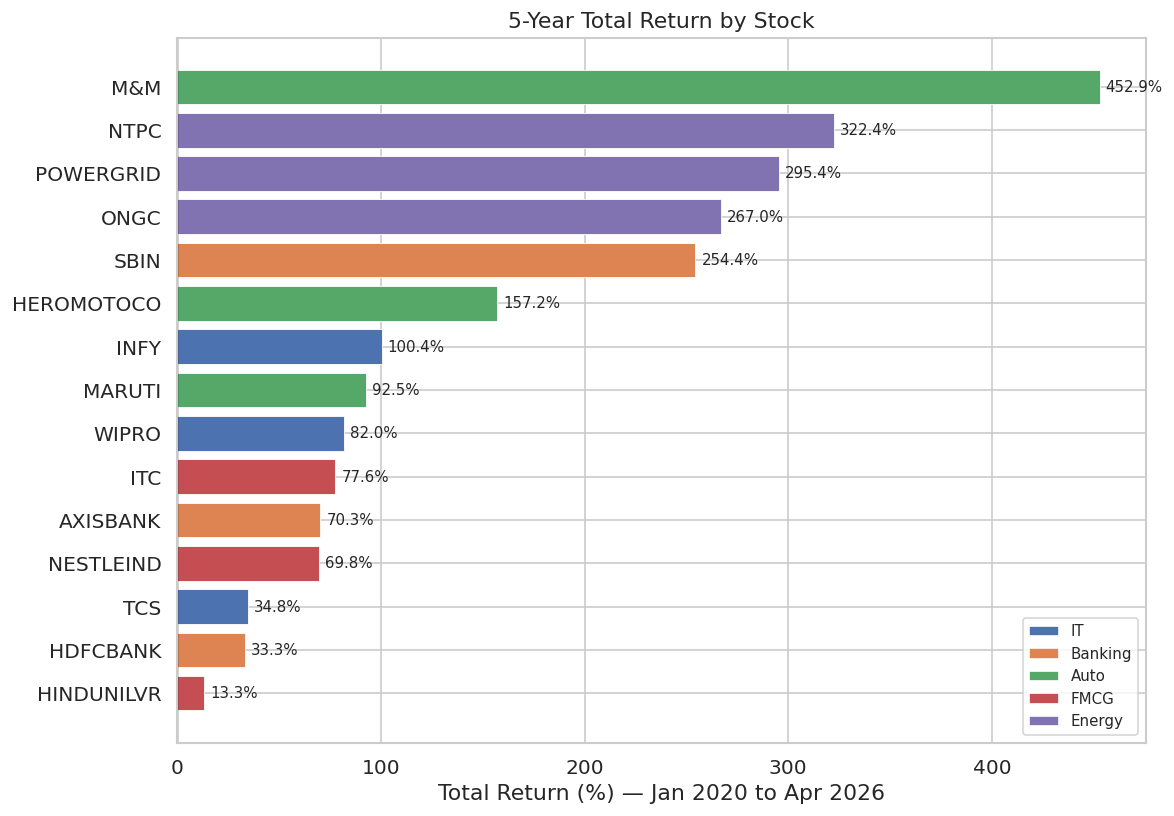

In [5]:
# ── 2.1 Total return comparison (bar chart) ───────────────────────────────────
summary_sorted = summary.sort_values('total_return_pct', ascending=True)
colors = [SECTOR_COLORS[s] for s in summary_sorted['sector']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(summary_sorted['ticker'].str.replace('.NS',''), 
               summary_sorted['total_return_pct'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, summary_sorted['total_return_pct']):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in SECTOR_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Total Return (%) — Jan 2020 to Apr 2026')
ax.set_title('5-Year Total Return by Stock')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('plots/01_total_returns.png', bbox_inches='tight')
plt.show()

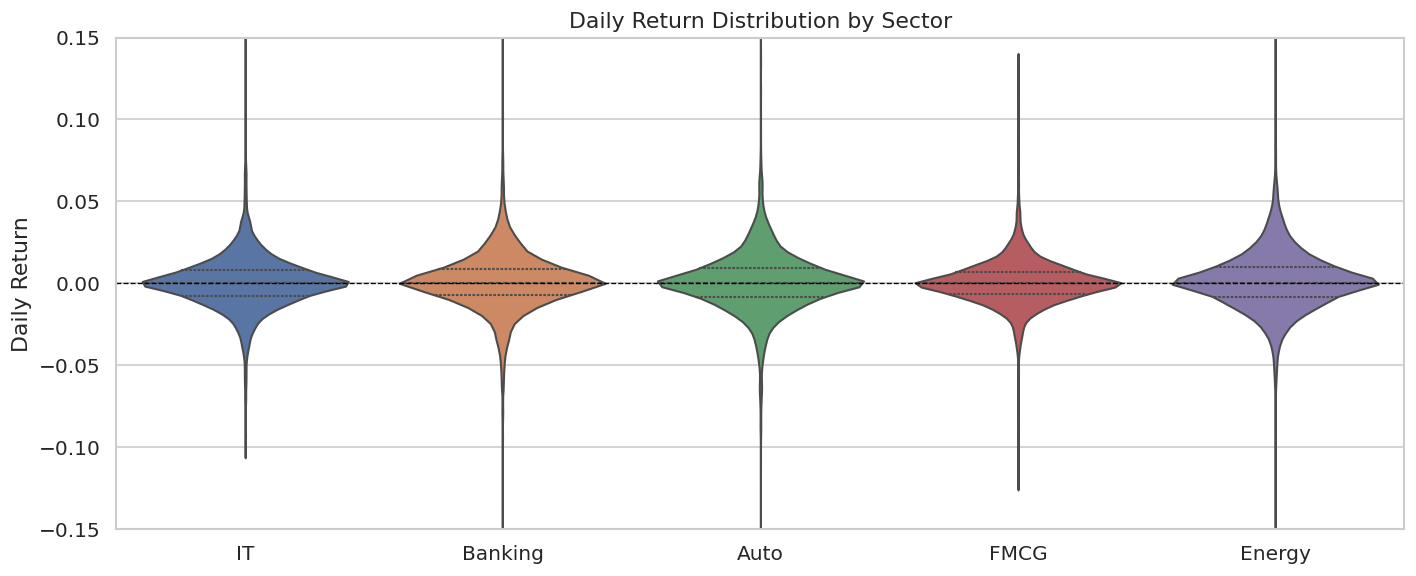

In [6]:
# ── 2.2 Daily return distribution — violin plot by sector ─────────────────────
import os
os.makedirs('plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=df, x='sector', y='daily_return',
    palette=SECTOR_COLORS, inner='quartile', ax=ax
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily Return Distribution by Sector')
ax.set_ylabel('Daily Return')
ax.set_xlabel('')
ax.set_ylim(-0.15, 0.15)
plt.tight_layout()
plt.savefig('plots/02_return_distribution.png', bbox_inches='tight')
plt.show()

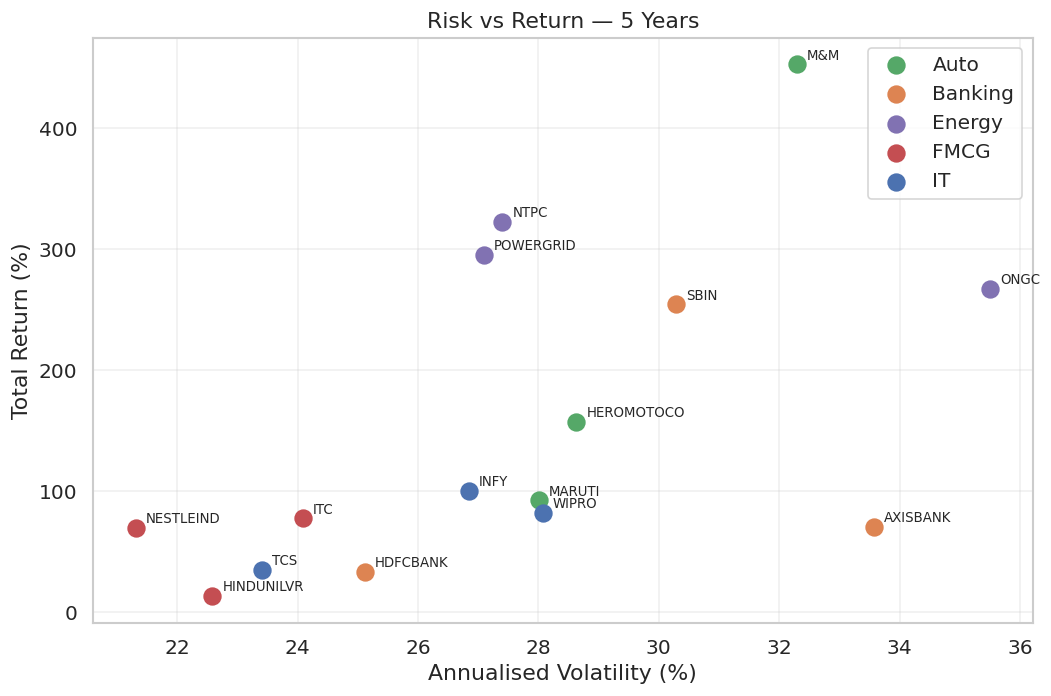

In [7]:
# ── 2.3 Annualised volatility vs total return (scatter) ───────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for sector, group in summary.groupby('sector'):
    ax.scatter(group['annualised_vol'], group['total_return_pct'],
               color=SECTOR_COLORS[sector], label=sector, s=100, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['ticker'].replace('.NS',''), 
                    (row['annualised_vol'], row['total_return_pct']),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Total Return (%)')
ax.set_title('Risk vs Return — 5 Years')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/03_risk_vs_return.png', bbox_inches='tight')
plt.show()

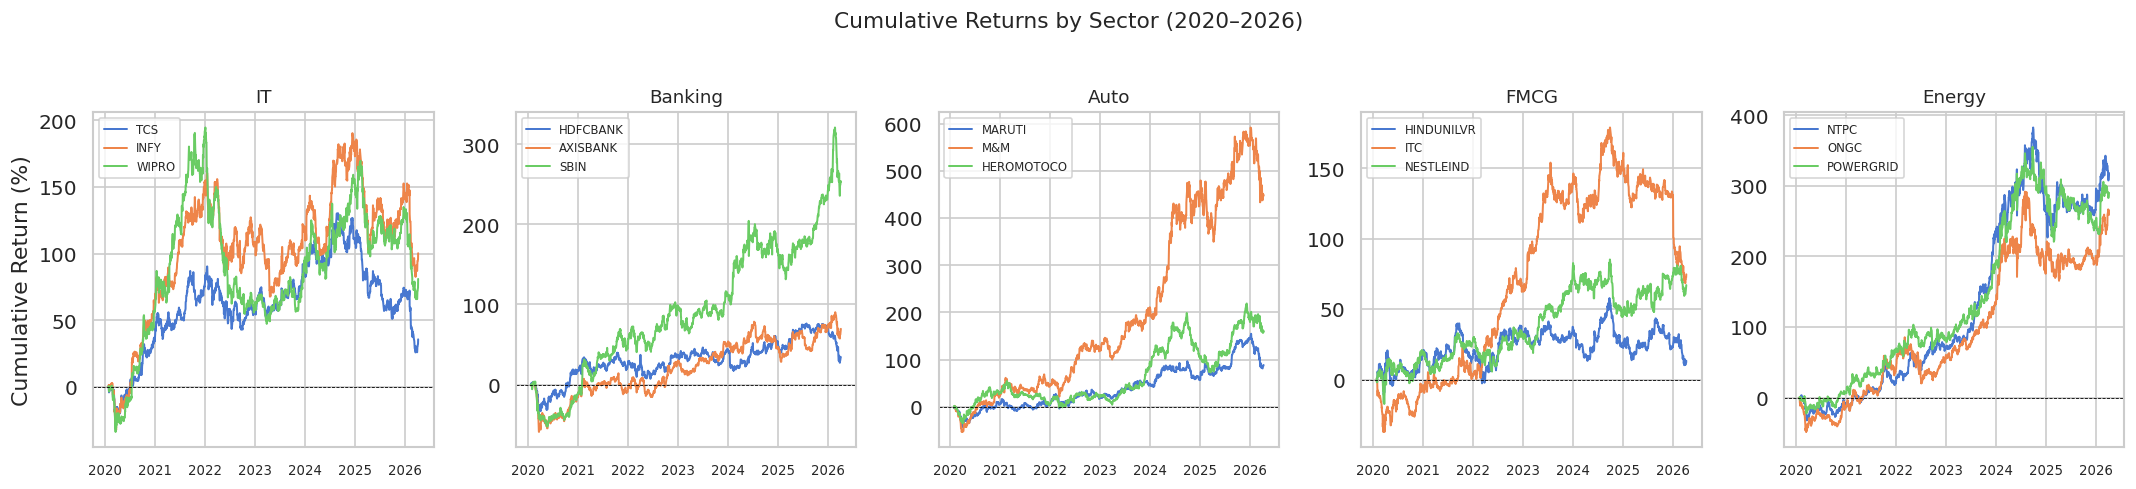

In [ ]:
# ── 2.4 Cumulative return over time (line chart, all 15 stocks) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for ax, (sector, tickers) in zip(axes, TICKERS.items()):
    for ticker in tickers:
        stock_df = df[df['ticker'] == ticker].sort_index()
        cum_ret = (1 + stock_df['daily_return']).cumprod() - 1
        ax.plot(cum_ret.index, cum_ret * 100, label=ticker.replace('.NS',''), linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(sector, fontsize=11)
    ax.legend(fontsize=7)
    ax.set_ylabel('Cumulative Return (%)' if ax == axes[0] else '')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Cumulative Returns by Sector (2020–2026)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('plots/04_cumulative_returns.png', bbox_inches='tight')
plt.show()

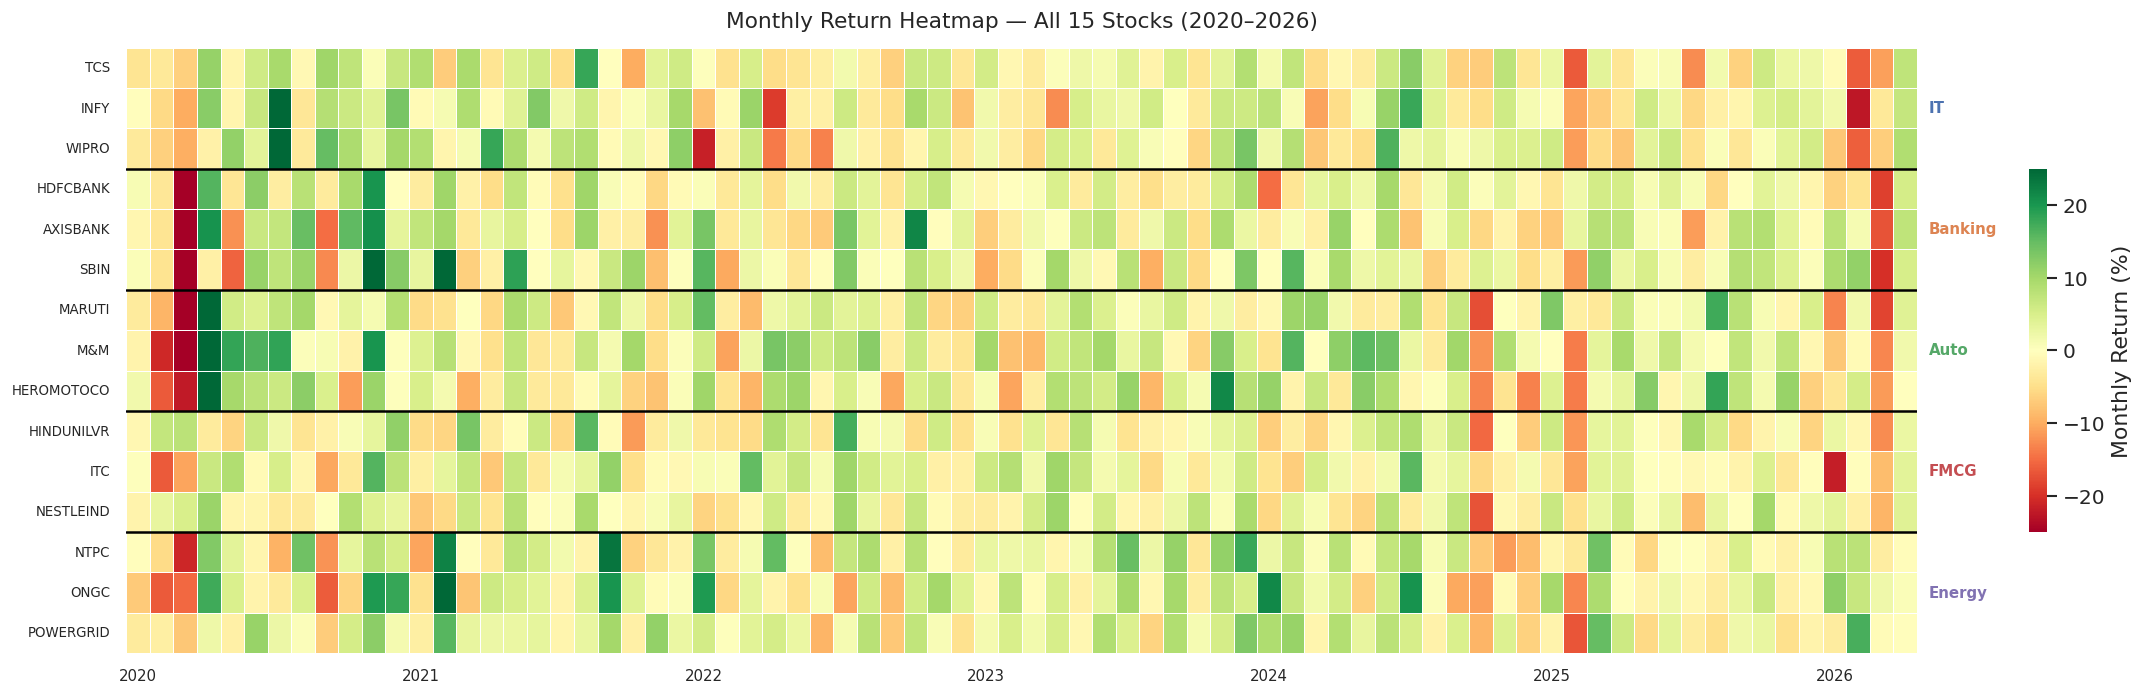

In [9]:
# ── 2.5 Monthly return heatmap ────────────────────────────────────────────────
# Pivot: stocks on Y, year-month on X, value = avg monthly return
df['year_month'] = df.index.to_period('M')

monthly = (
    df.groupby(['ticker', 'year_month'])['daily_return']
    .sum()                                    # sum of daily returns ≈ monthly return
    .reset_index()
)
monthly['year_month_str'] = monthly['year_month'].astype(str)
monthly['ticker_clean']   = monthly['ticker'].str.replace('.NS', '')

# Sector order for Y-axis
sector_order = [t.replace('.NS','') for s in TICKERS for t in TICKERS[s]]
pivot_monthly = monthly.pivot(index='ticker_clean', columns='year_month_str', values='daily_return')
pivot_monthly = pivot_monthly.loc[sector_order]  # reorder rows by sector

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(
    pivot_monthly * 100,
    cmap='RdYlGn', center=0, vmin=-25, vmax=25,
    linewidths=0.3, linecolor='white',
    annot=False, ax=ax,
    cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6}
)

# Draw sector divider lines
sector_sizes = [3, 3, 3, 3, 3]
dividers = [sum(sector_sizes[:i]) for i in range(1, len(sector_sizes))]
for d in dividers:
    ax.axhline(d, color='black', linewidth=1.5)

# Sector labels on the right
sector_names = list(TICKERS.keys())
prev = 0
for name, size in zip(sector_names, sector_sizes):
    mid = prev + size / 2
    ax.text(pivot_monthly.shape[1] + 0.5, mid, name,
            va='center', ha='left', fontsize=9, fontweight='bold',
            color=SECTOR_COLORS[name])
    prev += size

# X-axis: show only Jan of each year to reduce clutter
cols = pivot_monthly.columns.tolist()
xtick_pos   = [i for i, c in enumerate(cols) if c.endswith('-01')]
xtick_label = [c[:4] for c in cols if c.endswith('-01')]
ax.set_xticks([p + 0.5 for p in xtick_pos])
ax.set_xticklabels(xtick_label, rotation=0, fontsize=9)

ax.set_title('Monthly Return Heatmap — All 15 Stocks (2020–2026)', fontsize=13, pad=12)
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('plots/05_monthly_heatmap.png', bbox_inches='tight')
plt.show()


## 3. Correlation Analysis

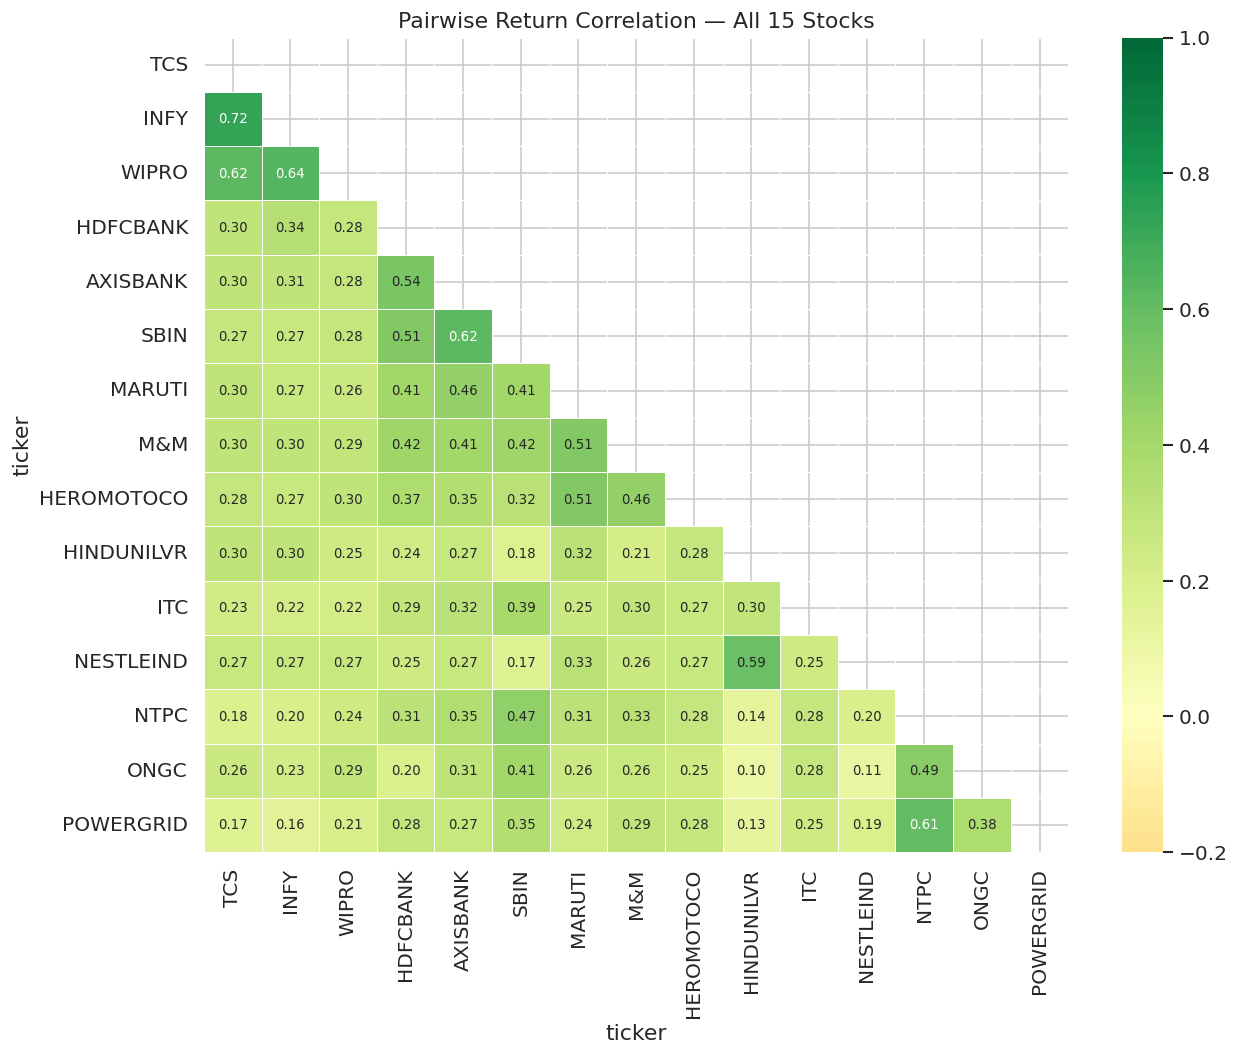


Observation: stocks within the same sector tend to be more correlated with each other.


In [10]:
# ── 3.1 Cross-stock return correlation heatmap ────────────────────────────────
# Pivot to wide format: date × ticker
pivot = df.pivot_table(index=df.index, columns='ticker', values='daily_return')
pivot.columns = pivot.columns.str.replace('.NS', '')
corr = pivot.corr()

# Reorder by sector
order = [t.replace('.NS','') for s in TICKERS for t in TICKERS[s]]
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.2, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Pairwise Return Correlation — All 15 Stocks')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('\nObservation: stocks within the same sector tend to be more correlated with each other.')

## 4. RSI Analysis

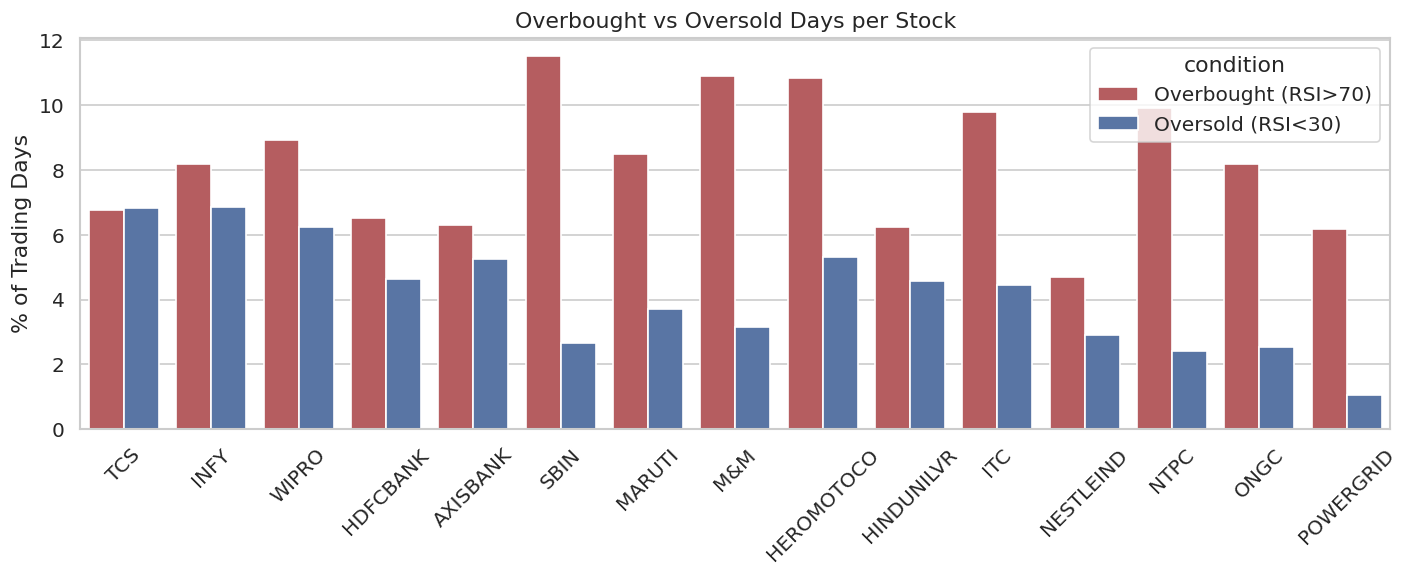

In [11]:
# ── 4.2 % of days overbought vs oversold by stock ─────────────────────────────
rsi_df = summary[['ticker','sector','pct_days_overbought','pct_days_oversold']].copy()
rsi_df['ticker'] = rsi_df['ticker'].str.replace('.NS', '')
rsi_melt = rsi_df.melt(id_vars=['ticker','sector'], 
                        value_vars=['pct_days_overbought','pct_days_oversold'],
                        var_name='condition', value_name='pct')
rsi_melt['condition'] = rsi_melt['condition'].map({
    'pct_days_overbought': 'Overbought (RSI>70)',
    'pct_days_oversold':   'Oversold (RSI<30)'
})

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=rsi_melt, x='ticker', y='pct', hue='condition',
    palette={'Overbought (RSI>70)': '#C44E52', 'Oversold (RSI<30)': '#4C72B0'},
    ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('% of Trading Days')
ax.set_title('Overbought vs Oversold Days per Stock')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/08_rsi_overbought_oversold.png', bbox_inches='tight')
plt.show()

## 5. Volatility Analysis

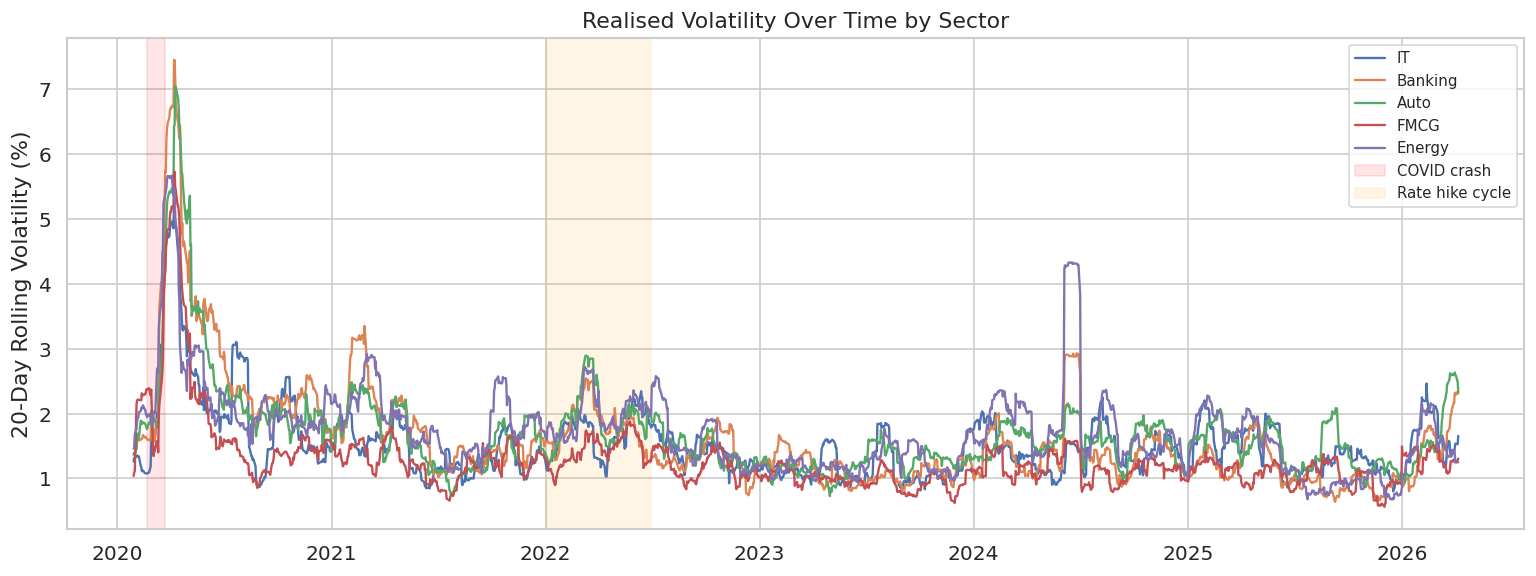

In [12]:
# ── 5.1 Rolling 20-day volatility over time — one line per sector ─────────────
fig, ax = plt.subplots(figsize=(13, 5))

for sector, tickers in TICKERS.items():
    sector_df = df[df['sector'] == sector].copy()
    # Average rolling vol across tickers in sector, by date
    avg_vol = sector_df.groupby(sector_df.index)['rolling_vol_20'].mean()
    ax.plot(avg_vol.index, avg_vol * 100, label=sector, 
            color=SECTOR_COLORS[sector], linewidth=1.4)

# Mark COVID crash
ax.axvspan('2020-02-20', '2020-03-23', alpha=0.1, color='red', label='COVID crash')
ax.axvspan('2022-01-01', '2022-06-30', alpha=0.1, color='orange', label='Rate hike cycle')

ax.set_ylabel('20-Day Rolling Volatility (%)')
ax.set_title('Realised Volatility Over Time by Sector')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plots/09_rolling_volatility.png', bbox_inches='tight')
plt.show()

## 6. MACD Analysis

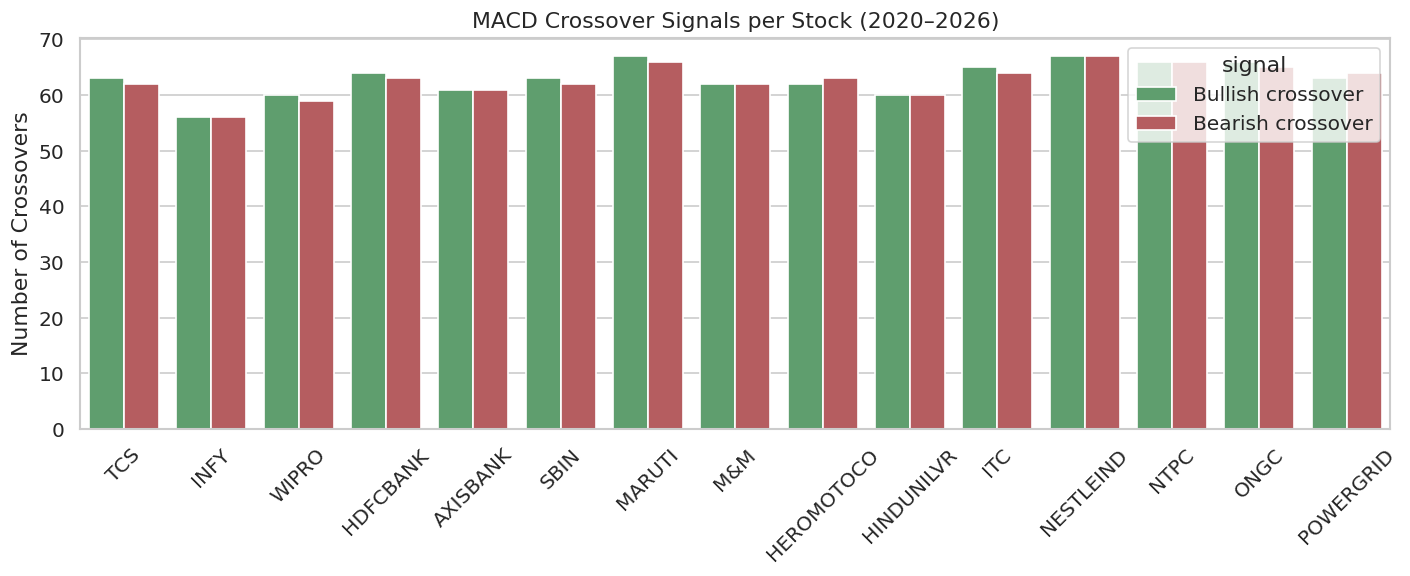

In [13]:
# ── 6.1 MACD signal frequency by stock ───────────────────────────────────────
macd_df = summary[['ticker','sector','macd_bullish_signals','macd_bearish_signals']].copy()
macd_df['ticker'] = macd_df['ticker'].str.replace('.NS','')
macd_melt = macd_df.melt(id_vars=['ticker','sector'],
                          value_vars=['macd_bullish_signals','macd_bearish_signals'],
                          var_name='signal', value_name='count')
macd_melt['signal'] = macd_melt['signal'].map({
    'macd_bullish_signals': 'Bullish crossover',
    'macd_bearish_signals': 'Bearish crossover'
})

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=macd_melt, x='ticker', y='count', hue='signal',
    palette={'Bullish crossover': '#55A868', 'Bearish crossover': '#C44E52'},
    ax=ax
)
ax.set_title('MACD Crossover Signals per Stock (2020–2026)')
ax.set_xlabel('')
ax.set_ylabel('Number of Crossovers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/11_macd_signals.png', bbox_inches='tight')
plt.show()

## 7. Interactive Plotly Charts

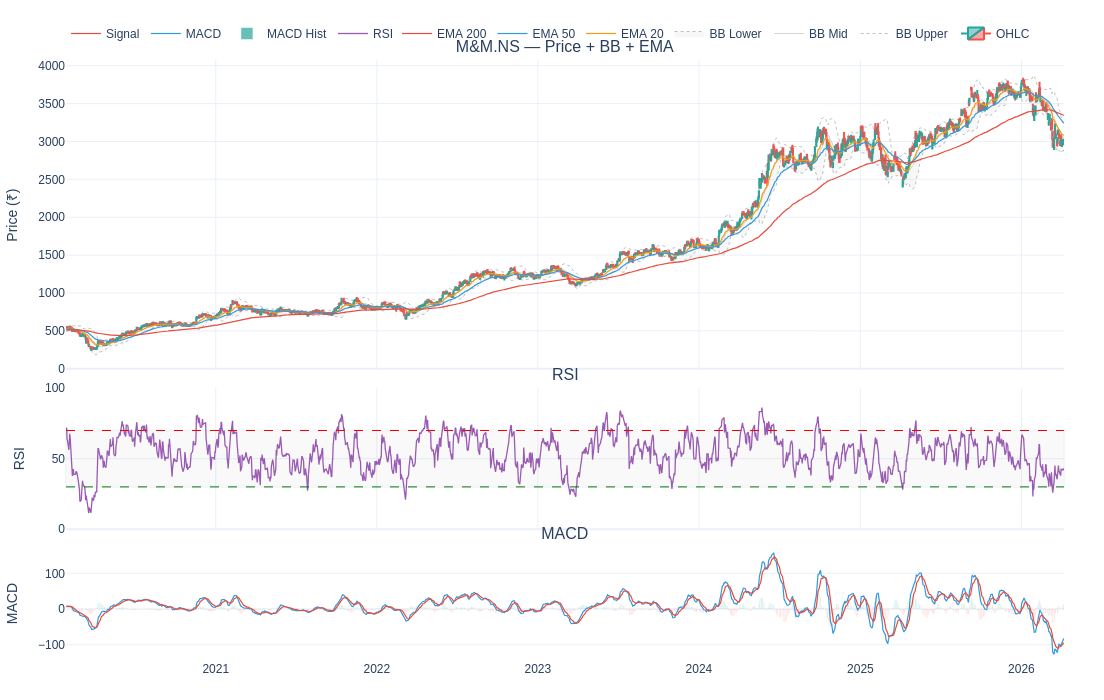

In [14]:
# ── 8.1 Interactive candlestick with Bollinger Bands + EMA for one stock ──────
# Change TICKER_TO_PLOT to explore any stock
TICKER_TO_PLOT = 'M&M.NS'

stock = df[df['ticker'] == TICKER_TO_PLOT].sort_index()

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    row_heights=[0.55, 0.25, 0.20],
    vertical_spacing=0.03,
    subplot_titles=[f'{TICKER_TO_PLOT} — Price + BB + EMA', 'RSI', 'MACD']
)

# Candlestick
fig.add_trace(go.Candlestick(
    x=stock.index, open=stock['Open'], high=stock['High'],
    low=stock['Low'], close=stock['Close'],
    name='OHLC', increasing_line_color='#26a69a', decreasing_line_color='#ef5350'
), row=1, col=1)

# Bollinger Bands
fig.add_trace(go.Scatter(x=stock.index, y=stock['bb_upper'], name='BB Upper',
    line=dict(color='rgba(150,150,150,0.6)', width=1, dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['bb_mid'], name='BB Mid',
    line=dict(color='rgba(150,150,150,0.4)', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['bb_lower'], name='BB Lower',
    fill='tonexty', fillcolor='rgba(150,150,150,0.08)',
    line=dict(color='rgba(150,150,150,0.6)', width=1, dash='dot')), row=1, col=1)

# EMAs
fig.add_trace(go.Scatter(x=stock.index, y=stock['ema_20'],  name='EMA 20',
    line=dict(color='#f39c12', width=1.2)), row=1, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['ema_50'],  name='EMA 50',
    line=dict(color='#3498db', width=1.2)), row=1, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['ema_200'], name='EMA 200',
    line=dict(color='#e74c3c', width=1.2)), row=1, col=1)

# RSI
fig.add_trace(go.Scatter(x=stock.index, y=stock['rsi'], name='RSI',
    line=dict(color='#9b59b6', width=1.3)), row=2, col=1)
fig.add_hline(y=70, line_dash='dash', line_color='red',   line_width=1, row=2, col=1)
fig.add_hline(y=30, line_dash='dash', line_color='green', line_width=1, row=2, col=1)
fig.add_hrect(y0=30, y1=70, fillcolor='gray', opacity=0.05, row=2, col=1)

# MACD
colors_hist = ['#26a69a' if v >= 0 else '#ef5350' for v in stock['macd_hist']]
fig.add_trace(go.Bar(x=stock.index, y=stock['macd_hist'], name='MACD Hist',
    marker_color=colors_hist, opacity=0.7), row=3, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['macd'], name='MACD',
    line=dict(color='#3498db', width=1.2)), row=3, col=1)
fig.add_trace(go.Scatter(x=stock.index, y=stock['macd_signal'], name='Signal',
    line=dict(color='#e74c3c', width=1.2)), row=3, col=1)

fig.update_layout(
    height=700, template='plotly_white',
    xaxis_rangeslider_visible=False,
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    margin=dict(l=40, r=40, t=60, b=40)
)
fig.update_yaxes(title_text='Price (₹)', row=1, col=1)
fig.update_yaxes(title_text='RSI',       row=2, col=1, range=[0, 100])
fig.update_yaxes(title_text='MACD',      row=3, col=1)

fig.show()
fig.write_html('plots/15_interactive_chart.html')

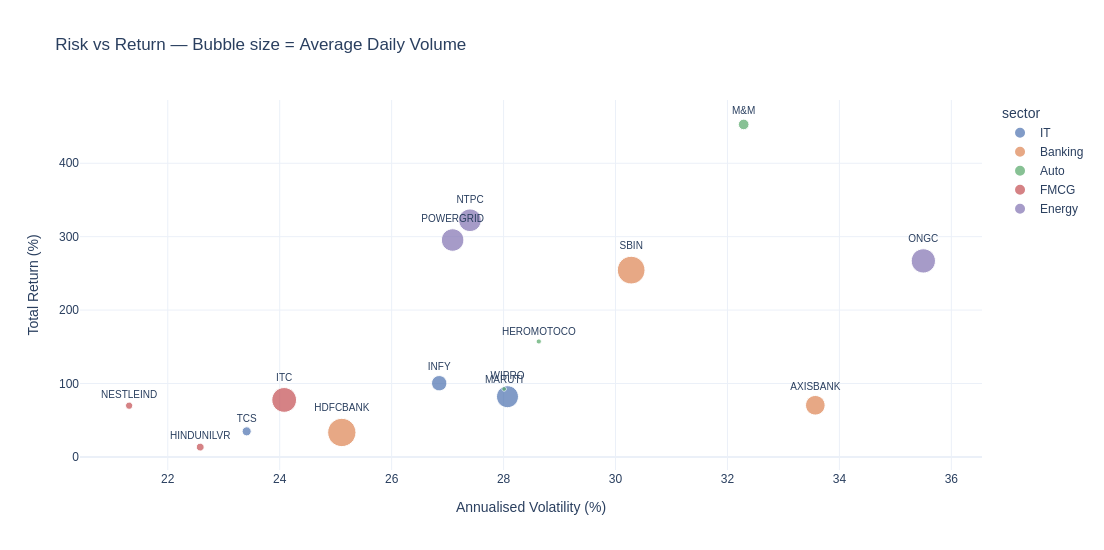

In [15]:
# ── 8.2 Interactive sector comparison — total return bubble chart ──────────────
summary_plot = summary.copy()
summary_plot['label'] = summary_plot['ticker'].str.replace('.NS', '')

fig = px.scatter(
    summary_plot,
    x='annualised_vol', y='total_return_pct',
    color='sector', size='avg_volume',
    text='label', hover_data=['max_drawdown_pct', 'avg_rsi', 'avg_atr_pct'],
    color_discrete_map=SECTOR_COLORS,
    title='Risk vs Return — Bubble size = Average Daily Volume',
    labels={
        'annualised_vol': 'Annualised Volatility (%)',
        'total_return_pct': 'Total Return (%)',
    }
)
fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(height=550, template='plotly_white')
fig.show()
fig.write_html('plots/16_bubble_chart.html')

## 8. Key Findings Summary

In [16]:
print('=' * 60)
print('KEY EDA FINDINGS')
print('=' * 60)

print('\n1. RETURNS')
best  = summary.loc[summary['total_return_pct'].idxmax()]
worst = summary.loc[summary['total_return_pct'].idxmin()]
print(f'   Best performer : {best["ticker"]} ({best["total_return_pct"]:.1f}%)')
print(f'   Worst performer: {worst["ticker"]} ({worst["total_return_pct"]:.1f}%)')

print('\n2. RISK')
most_vol  = summary.loc[summary['annualised_vol'].idxmax()]
least_vol = summary.loc[summary['annualised_vol'].idxmin()]
print(f'   Most volatile  : {most_vol["ticker"]} ({most_vol["annualised_vol"]:.1f}% annualised vol)')
print(f'   Least volatile : {least_vol["ticker"]} ({least_vol["annualised_vol"]:.1f}% annualised vol)')

print('\n3. RSI')
most_ob = summary.loc[summary['pct_days_overbought'].idxmax()]
most_os = summary.loc[summary['pct_days_oversold'].idxmax()]
print(f'   Most overbought: {most_ob["ticker"]} ({most_ob["pct_days_overbought"]:.1f}% of days)')
print(f'   Most oversold  : {most_os["ticker"]} ({most_os["pct_days_oversold"]:.1f}% of days)')

print('\n4. DRAWDOWN')
worst_dd = summary.loc[summary['max_drawdown_pct'].idxmin()]
best_dd  = summary.loc[summary['max_drawdown_pct'].idxmax()]
print(f'   Worst drawdown : {worst_dd["ticker"]} ({worst_dd["max_drawdown_pct"]:.1f}%)')
print(f'   Best drawdown  : {best_dd["ticker"]}  ({best_dd["max_drawdown_pct"]:.1f}%)')

print('\n5. SECTOR AVERAGES')
sector_avg = summary.groupby('sector')[['total_return_pct','annualised_vol','avg_rsi']].mean().round(2)
print(sector_avg.to_string())
print('=' * 60)

KEY EDA FINDINGS

1. RETURNS
   Best performer : M&M.NS (452.9%)
   Worst performer: HINDUNILVR.NS (13.3%)

2. RISK
   Most volatile  : ONGC.NS (35.5% annualised vol)
   Least volatile : NESTLEIND.NS (21.3% annualised vol)

3. RSI
   Most overbought: SBIN.NS (11.5% of days)
   Most oversold  : INFY.NS (6.9% of days)

4. DRAWDOWN
   Worst drawdown : AXISBANK.NS (-59.9%)
   Best drawdown  : NESTLEIND.NS  (-22.9%)

5. SECTOR AVERAGES
         total_return_pct  annualised_vol  avg_rsi
sector                                            
Auto               234.22           29.64    53.03
Banking            119.32           29.65    52.67
Energy             294.94           30.00    53.48
FMCG                53.57           22.66    51.31
IT                  72.38           26.11    51.70
